# Statistical Techniques Project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("students_scores.csv")

print("Population Data Loaded Successfully.")

#Shape 
print("Shape (Rows, Columns):", df.shape)

print(df.head())

Population Data Loaded Successfully.
Shape (Rows, Columns): (500, 3)
   Gender      Score Score_Category
0    Male  66.532063         Medium
1  Female  62.851528         Medium
2    Male  70.534850           High
3    Male  83.563988           High
4    Male  77.140937           High


# Types of Sampling

## A. PROBABILITY SAMPLING: Every member has equal / known chance.

### 1. SIMPLE RANDOM SAMPLING: Every student has equal chance 
    sample() = randomly selects data

In [3]:
#Take random 10 students
random_sample = df.sample(n=10)

print("\n Simple Random Sampling (10 Students):")
print(random_sample)


 Simple Random Sampling (10 Students):
     Gender      Score Score_Category
41     Male  81.795977           High
143  Female  69.027456         Medium
216  Female  73.499345           High
408  Female  75.301251           High
409  Female  68.212363         Medium
214    Male  75.052437           High
3      Male  83.563988           High
426    Male  99.457520           High
288    Male  80.765570           High
316    Male  68.493574         Medium


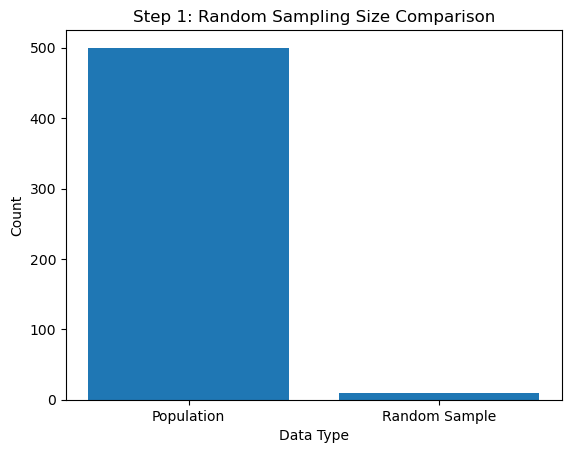

In [4]:
# bar chart (compare sizes)
labels = ['Population', 'Random Sample']
#Values (count rows)
sizes = [len(df), len(random_sample)]
#Plot bar chart
plt.figure()
plt.bar(labels,sizes)

plt.title("Step 1: Random Sampling Size Comparison")
plt.xlabel("Data Type")
plt.ylabel("Count")
plt.show()

### 2. SYSTEMATIC SAMPLING

In [5]:
#Picks every 5th student (skip 4, take 1)
systematic_sample = df.iloc[::5]

print("\n Systematic Sampling (Every 5th Student):")
print(systematic_sample.head())


 Systematic Sampling (Every 5th Student):
    Gender      Score Score_Category
0     Male  66.532063         Medium
5   Female  65.542612         Medium
10    Male  75.582087           High
15    Male  85.538021           High
20  Female  83.150477           High


### 3. STRATIFIED SAMPLING = take equal data from each group

In [7]:
#Check if Gender column exists in dataset
if "Gender" in df.columns:
    stratified_sample = df.groupby("Gender").sample(50)

    print("\n Stratified Sampling (equal from each Gender):")
    print(stratified_sample)
else:
    print("\n Stratified Sampling skipped (No 'Gender' column found)")


 Stratified Sampling (equal from each Gender):
     Gender      Score Score_Category
27   Female  85.589692           High
120  Female  83.470974           High
350  Female  88.062928           High
435  Female  91.454200           High
93   Female  84.621307           High
..      ...        ...            ...
498    Male  72.596746           High
448    Male  83.231706           High
205    Male  93.314588           High
327    Male  82.553912           High
12     Male  78.577874           High

[100 rows x 3 columns]


### 4. CLUSTER SAMPLING = pick one full group (cluster)

In [8]:
df["Cluster"] = np.random.randint(1,6, len(df))

#pick one random cluster (like class 3)
selected_cluster = np.random.choice(df["Cluster"].unique())

#Take all students from that cluster
cluster_sample = df[df["Cluster"] == selected_cluster]

print("\n Cluster Sampling (Selected Cluster =", selected_cluster, ")")
print(cluster_sample.head())


 Cluster Sampling (Selected Cluster = 4 )
    Gender      Score Score_Category  Cluster
1   Female  62.851528         Medium        4
5   Female  65.542612         Medium        4
9   Female  79.537251           High        4
18  Female  83.150353           High        4
19    Male  80.137860           High        4


## B. NON-PROBABILITY SAMPLING: Not everyone has equal chance

### 1. CONVENIENCE SAMPLING: Select easy data (first rows)
Take what is quick and available (not random)

In [9]:
convenience_sample = df.head(10)

print("\n Convenience Sampling (First 0 rows)")

print(convenience_sample)


 Convenience Sampling (First 0 rows)
   Gender      Score Score_Category  Cluster
0    Male  66.532063         Medium        1
1  Female  62.851528         Medium        4
2    Male  70.534850           High        3
3    Male  83.563988           High        3
4    Male  77.140937           High        2
5  Female  65.542612         Medium        4
6    Male  76.731809           High        2
7    Male  78.853174           High        5
8    Male  66.161426         Medium        3
9  Female  79.537251           High        4


### 2. JUDGEMENTAL SAMPLING = Select data by condition (your choice)
judgemental = choose by condition

In [10]:
if "Score" in df.columns:
    #Select students with marks > 80 (high performance)

    #head(10) take first 10 from the filtered data
    judgement_sample = df[df["Score"] > 80].head(10)
    print("\n Judgemental Sampling (High Math Scores):")
    print(judgement_sample)

else:
    print("\n Judgemental Sampling Skipped (No Math Score column)")


 Judgemental Sampling (High Math Scores):
    Gender       Score Score_Category  Cluster
3     Male   83.563988           High        3
13    Male   80.607845           High        2
14  Female   88.830512           High        2
15    Male   85.538021           High        3
18  Female   83.150353           High        4
19    Male   80.137860           High        4
20  Female   83.150477           High        3
21    Male  100.000000           High        5
22  Female   83.708905           High        1
23  Female   89.355656           High        4


### 3. SNOWBALL SAMPLING = grow sample step by step (chain method)

In [11]:
#Start with two random students
snowball_sample = df.sample(2)

for i in range(3):

    #Pick 2 new random students
    new_sample = df.sample(2)

    #Add them to existing sample (combine data)
    snowball_sample = pd.concat([snowball_sample, new_sample])

print("\n Snowball Sampling (Simulated Chain):")
print(snowball_sample)


 Snowball Sampling (Simulated Chain):
     Gender      Score Score_Category  Cluster
472    Male  69.263380         Medium        4
368    Male  70.123938           High        3
341  Female  68.956834         Medium        2
209    Male  88.538724           High        1
446    Male  64.878956         Medium        2
4      Male  77.140937           High        2
478    Male  72.450228           High        4
144  Female  78.758046           High        4


### 4. QUOTA SAMPLING = fixed number from each group

In [13]:
if "Gender" in df.columns:
    #Take 5 Males
    male_sample = df[df["Gender"] == "Male"].head(5)

    #Take 5 females
    female_sample = df[df["Gender"] == "Female"].head(5)

    #Combine both groups
    quota_sample = pd.concat([male_sample, female_sample])

    print("\n Quota Sampling (5 Male + 5 Females):")
    print(quota_sample)

else:
    print("\n Quota Sampling Skipped (No 'Gender' column)")


 Quota Sampling (5 Male + 5 Females):
    Gender      Score Score_Category  Cluster
0     Male  66.532063         Medium        1
2     Male  70.534850           High        3
3     Male  83.563988           High        3
4     Male  77.140937           High        2
6     Male  76.731809           High        2
1   Female  62.851528         Medium        4
5   Female  65.542612         Medium        4
9   Female  79.537251           High        4
14  Female  88.830512           High        2
16  Female  64.223306         Medium        1


# FINAL SUMMARY

show sizes of all samples (Compare original data vs sampled data size)

In [14]:
print("FINAL SUMMARY")

#Total data (all students)
print("Population Size:", len(df))

#Random Sample Count
print("Random Sample Size:", len(random_sample))

#Systematic Sample Count
print("Systematic Sample Size:", len(systematic_sample))

#Cluster sample count
print("Cluster Sample Size:", len(cluster_sample))

FINAL SUMMARY
Population Size: 500
Random Sample Size: 10
Systematic Sample Size: 100
Cluster Sample Size: 120
